In [ ]:
import zipfile
import os

# Path to your zip file
zip_path = "/content/merged.zip"

# Destination folder to extract to
extract_path = "merged_sign"

# Create the destination folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Extracted '{zip_path}' to '{extract_path}'")

Extracted '/content/merged.zip' to 'merged_sign'


In [ ]:
!pip install tensorflow spektral opencv-python mediapipe numpy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 30.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.12.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.7

In [ ]:
!pip install tensorflow opencv-python numpy scikit-learn spektral mediapipe matplotlib seaborn pandas

In [ ]:
import os
import cv2
import mediapipe as mp
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import random
import math

class ISLDataset:
    def __init__(self, dataset_path, img_size=(224, 224), validation_split=0.2, test_split=0.1, random_state=42):
        self.dataset_path = dataset_path
        self.img_size = img_size
        self.validation_split = validation_split
        self.test_split = test_split
        self.random_state = random_state

        # Sort classes alphabetically to ensure consistent indexing
        self.classes = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])

        self.mp_hands = mp.solutions.hands
        self.all_data = []

        if not self.classes:
            raise ValueError(f"No class subdirectories found in {dataset_path}. Please organize your dataset into subfolders, e.g., 'A/', 'B/', etc.")

    def _augment_landmarks(self, landmarks):
        """
        Applies various augmentations to 3D hand landmarks.
        `landmarks` is a flat array of 63 values (21 * 3).
        """
        augmented_landmarks = landmarks.reshape(-1, 3).copy() # Reshape to (21, 3)

        # 1. Random Scaling (around a central point, e.g., wrist 0)
        scale_factor = np.random.uniform(0.9, 1.1) # Scale between 90% and 110%
        # Translate to origin, scale, then translate back
        center_point = augmented_landmarks[0] # Using wrist as origin for scaling/rotation
        augmented_landmarks = (augmented_landmarks - center_point) * scale_factor + center_point

        # 2. Random Rotation (around Z-axis for 2D/3D planar rotation, adjust if full 3D rotation needed)
        angle_degrees = np.random.uniform(-15, 15) # Rotate +/- 15 degrees
        angle_rad = math.radians(angle_degrees)
        rotation_matrix = np.array([
            [math.cos(angle_rad), -math.sin(angle_rad), 0],
            [math.sin(angle_rad), math.cos(angle_rad), 0],
            [0, 0, 1]
        ])
        augmented_landmarks = np.dot(augmented_landmarks - center_point, rotation_matrix) + center_point

        # 3. Random Translation (shift) - apply to normalized coordinates
        # Since landmarks are normalized (0-1), a small shift is appropriate
        shift_range = 0.05
        shift_x = np.random.uniform(-shift_range, shift_range)
        shift_y = np.random.uniform(-shift_range, shift_range)
        shift_z = np.random.uniform(-shift_range, shift_range) # Less impactful for 2D projections
        augmented_landmarks[:, 0] += shift_x
        augmented_landmarks[:, 1] += shift_y
        augmented_landmarks[:, 2] += shift_z

        # 4. Add small random noise
        noise_level = 0.005 # Small Gaussian noise
        noise = np.random.normal(loc=0.0, scale=noise_level, size=augmented_landmarks.shape)
        augmented_landmarks += noise

        return augmented_landmarks.flatten() # Flatten back to 1D

    def load_and_preprocess_data(self):
        print("Loading and preprocessing data...")
        with self.mp_hands.Hands(
            static_image_mode=True,
            max_num_hands=1, # Focus on single hand for ISL letters typically
            min_detection_confidence=0.7
        ) as hands:
            for class_idx, class_name in enumerate(tqdm(self.classes, desc="Processing classes")):
                class_path = os.path.join(self.dataset_path, class_name)
                if not os.path.isdir(class_path):
                    print(f"Warning: Class directory {class_path} not found. Skipping.")
                    continue

                valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
                image_files = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]

                if not image_files:
                    print(f"Warning: No valid image files found in {class_path}. Skipping.")
                    continue

                for img_name in image_files:
                    img_path = os.path.join(class_path, img_name)

                    try:
                        img = cv2.imread(img_path)
                        if img is None:
                            print(f"Warning: Could not read image {img_path}. Skipping.")
                            continue

                        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        # Resize for consistent MediaPipe processing, but keep aspect ratio or pad if needed
                        # For now, simple resize that might distort aspect, but MediaPipe might be robust
                        img_resized = cv2.resize(img_rgb, self.img_size, interpolation=cv2.INTER_AREA)

                        results = hands.process(img_resized)

                        if results.multi_hand_landmarks:
                            # We take the first hand detected, as ISL often uses one hand per sign
                            hand_landmarks = results.multi_hand_landmarks[0]
                            landmarks = np.array([[lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark]).flatten()

                            self.all_data.append({
                                'landmarks': landmarks,
                                'label': class_idx
                            })

                            # Add augmented data (e.g., 3 augmented versions per original image)
                            for _ in range(3): # You can adjust the number of augmentations
                                self.all_data.append({
                                    'landmarks': self._augment_landmarks(landmarks),
                                    'label': class_idx
                                })
                        # else: # Optional: Log images where no hand is detected
                            # print(f"No hand detected in {img_path}")

                    except Exception as e:
                        print(f"Error processing {img_path}: {e}")
                        continue

        if not self.all_data:
            raise ValueError("No data was loaded. Check dataset path, image files, and MediaPipe's ability to detect hands.")

        # Save class names to a file for use in the prediction script
        classes_file_path = "classes_final_1.txt"
        with open(classes_file_path, 'w') as f:
            for cls_name in self.classes:
                f.write(f"{cls_name}\n")
        print(f"✅ Class names saved to {classes_file_path}")

        return self._prepare_graph_data()

    def _prepare_graph_data(self):
        num_landmarks = 21
        num_features_per_landmark = 3

        landmarks_list = [d['landmarks'].reshape(num_landmarks, num_features_per_landmark) for d in self.all_data]
        labels_list = [d['label'] for d in self.all_data]

        X = np.array(landmarks_list, dtype=np.float32)
        y = np.array(labels_list, dtype=np.int32)

        connections = [
            (0, 1), (1, 2), (2, 3), (3, 4), # Thumb
            (0, 5), (5, 6), (6, 7), (7, 8), # Index finger
            (0, 9), (9, 10), (10, 11), (11, 12), # Middle finger
            (0, 13), (13, 14), (14, 15), (15, 16), # Ring finger
            (0, 17), (17, 18), (18, 19), (19, 20), # Pinky finger
            (5, 9), (9, 13), (13, 17) # Connecting bases of fingers (metacarpals)
        ]

        A = np.zeros((len(self.all_data), num_landmarks, num_landmarks), dtype=np.float32)
        for i in range(len(self.all_data)):
            adj_matrix = np.eye(num_landmarks, dtype=np.float32) # Add self-loops
            for u, v in connections:
                adj_matrix[u, v] = 1.0
                adj_matrix[v, u] = 1.0
            A[i] = adj_matrix

        # Split data
        X_train_val, X_test, A_train_val, A_test, y_train_val, y_test = train_test_split(
            X, A, y, test_size=self.test_split, random_state=self.random_state, stratify=y
        )

        validation_size_relative_to_train_val = self.validation_split / (1 - self.test_split)

        X_train, X_val, A_train, A_val, y_train, y_val = train_test_split(
            X_train_val, A_train_val, y_train_val,
            test_size=validation_size_relative_to_train_val,
            random_state=self.random_state, stratify=y_train_val
        )

        print(f"\nDataset loaded. Total samples (including augmented): {len(self.all_data)}")
        print(f"Train samples: {len(X_train)}")
        print(f"Validation samples: {len(X_val)}")
        print(f"Test samples: {len(X_test)}")
        print(f"Number of classes: {len(self.classes)}")

        return (X_train, A_train, y_train), \
               (X_val, A_val, y_val), \
               (X_test, A_test, y_test)

if __name__ == '__main__':
    dataset_path = '/content/merged_sign/merged'

    try:
        dataset = ISLDataset(dataset_path)
        (X_train, A_train, y_train), (X_val, A_val, y_val), (X_test, A_test, y_test) = dataset.load_and_preprocess_data()

        print("\nShapes of the preprocessed data:")
        print(f"X_train shape: {X_train.shape}")
        print(f"A_train shape: {A_train.shape}")
        print(f"y_train shape: {y_train.shape}")
        print(f"Number of classes: {len(dataset.classes)}")
        print(f"Classes found: {dataset.classes}")

    except ValueError as e:
        print(f"Error: {e}")
        print("Please ensure 'ISL_Dataset' exists and contains subfolders with image files.")
    except FileNotFoundError:
        print(f"Error: Dataset path '{dataset_path}' not found.")
        print("Please ensure the dataset path is correct and the directory exists.")

Loading and preprocessing data...


Processing classes: 100%|██████████| 36/36 [30:19<00:00, 50.54s/it]


✅ Class names saved to classes_final_1.txt

Dataset loaded. Total samples (including augmented): 189572
Train samples: 132699
Validation samples: 37915
Test samples: 18958
Number of classes: 36

Shapes of the preprocessed data:
X_train shape: (132699, 21, 3)
A_train shape: (132699, 21, 21)
y_train shape: (132699,)
Number of classes: 36
Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


🔥 TensorFlow is using GPU: /physical_device:GPU:0

🚀 Starting training process for ISL GNN model using data from: /content/merged_sign/merged
Loading and preprocessing data...


Processing classes: 100%|██████████| 36/36 [31:09<00:00, 51.93s/it]


✅ Class names saved to classes_final_1.txt

Dataset loaded. Total samples (including augmented): 189572
Train samples: 132699
Validation samples: 37915
Test samples: 18958
Number of classes: 36


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ node_features       │ (None, 21, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adjacency_matrix    │ (None, 21, 21)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_gcn_conv     │ (None, 21, 256)   │      1,024 │ node_features[0]… │
│ (CustomGCNConv)     │                   │            │ adjacency_matrix… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 21, 256)   │      1,024 │ custom_gcn_conv[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 21, 256)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 21, 256)   │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_gcn_conv_1   │ (None, 21, 256)   │     65,792 │ dropout[0][0],    │
│ (CustomGCNConv)     │                   │            │ adjacency_matrix… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 256)   │      1,024 │ custom_gcn_conv_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 21, 256)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 21, 256)   │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_gcn_conv_2   │ (None, 21, 128)   │     32,896 │ dropout_1[0][0],  │
│ (CustomGCNConv)     │                   │            │ adjacency_matrix… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 128)   │        512 │ custom_gcn_conv_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 21, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 21, 128)   │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_sum_pool     │ (None, 128)       │          0 │ dropout_2[0][0]   │
│ (GlobalSumPool)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     33,024 │ global_sum_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

...

4147/4147 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - accuracy: 0.5953 - loss: 1.3952 - val_accuracy: 0.7967 - val_loss: 0.8256 - learning_rate: 5.0000e-04
Epoch 120/200
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5962 - loss: 1.3884
Epoch 120: val_accuracy did not improve from 0.79668
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.5962 - loss: 1.3884 - val_accuracy: 0.7927 - val_loss: 0.8268 - learning_rate: 5.0000e-04
Epoch 121/200
4139/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6009 - loss: 1.3782
Epoch 121: val_accuracy did not improve from 0.79668
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.6009 - loss: 1.3783 - val_accuracy: 0.7922 - val_loss: 0.8328 - learning_rate: 5.0000e-04
Epoch 122/200
4146/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5948 - loss: 1.3889
Epoch 122: val_accuracy did not improve from 0.79668
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.5948 - loss: 1.3889 - val_accuracy: 0.7837 - val_loss: 0.8401 - le

4147/4147 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.6019 - loss: 1.3744 - val_accuracy: 0.8010 - val_loss: 0.8105 - learning_rate: 5.0000e-04
Epoch 139/200
4144/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6015 - loss: 1.3827
Epoch 139: val_accuracy did not improve from 0.80103
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.6015 - loss: 1.3827 - val_accuracy: 0.7765 - val_loss: 0.8473 - learning_rate: 5.0000e-04
Epoch 140/200
4138/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5970 - loss: 1.3873
Epoch 140: val_accuracy did not improve from 0.80103
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - accuracy: 0.5970 - loss: 1.3873 - val_accuracy: 0.7887 - val_loss: 0.8372 - learning_rate: 5.0000e-04
Epoch 141/200
4139/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5952 - loss: 1.3922
Epoch 141: val_accuracy did not improve from 0.80103
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.5952 - loss: 1.3922 - val_accuracy: 0.7752 - val_loss: 0.8638 - le

4147/4147 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.6166 - loss: 1.3214 - val_accuracy: 0.8117 - val_loss: 0.7511 - learning_rate: 2.5000e-04
Epoch 171/200
4141/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6255 - loss: 1.2842
Epoch 171: val_accuracy improved from 0.81171 to 0.82529, saving model to best_isl_gnn_model.h5


4147/4147 ━━━━━━━━━━━━━━━━━━━━ 45s 7ms/step - accuracy: 0.6255 - loss: 1.2842 - val_accuracy: 0.8253 - val_loss: 0.7151 - learning_rate: 2.5000e-04
Epoch 172/200
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6284 - loss: 1.2741
Epoch 172: val_accuracy did not improve from 0.82529
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - accuracy: 0.6284 - loss: 1.2741 - val_accuracy: 0.8233 - val_loss: 0.7135 - learning_rate: 2.5000e-04
Epoch 173/200
4138/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6303 - loss: 1.2601
Epoch 173: val_accuracy did not improve from 0.82529
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.6303 - loss: 1.2602 - val_accuracy: 0.8205 - val_loss: 0.7253 - learning_rate: 2.5000e-04
Epoch 174/200
4142/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6266 - loss: 1.2626
Epoch 174: val_accuracy did not improve from 0.82529
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.6266 - loss: 1.2626 - val_accuracy: 0.8234 - val_loss: 0.7109 - le

4147/4147 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 0.6314 - loss: 1.2443 - val_accuracy: 0.8314 - val_loss: 0.6834 - learning_rate: 2.5000e-04
Epoch 181/200
4140/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6325 - loss: 1.2383
Epoch 181: val_accuracy did not improve from 0.83139
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.6325 - loss: 1.2383 - val_accuracy: 0.8190 - val_loss: 0.7024 - learning_rate: 2.5000e-04
Epoch 182/200
4140/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6339 - loss: 1.2423
Epoch 182: val_accuracy did not improve from 0.83139
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - accuracy: 0.6339 - loss: 1.2423 - val_accuracy: 0.8242 - val_loss: 0.6903 - learning_rate: 2.5000e-04
Epoch 183/200
4144/4147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6342 - loss: 1.2359
Epoch 183: val_accuracy did not improve from 0.83139
4147/4147 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.6342 - loss: 1.2359 - val_accuracy: 0.8258 - val_loss: 0.6833 - le

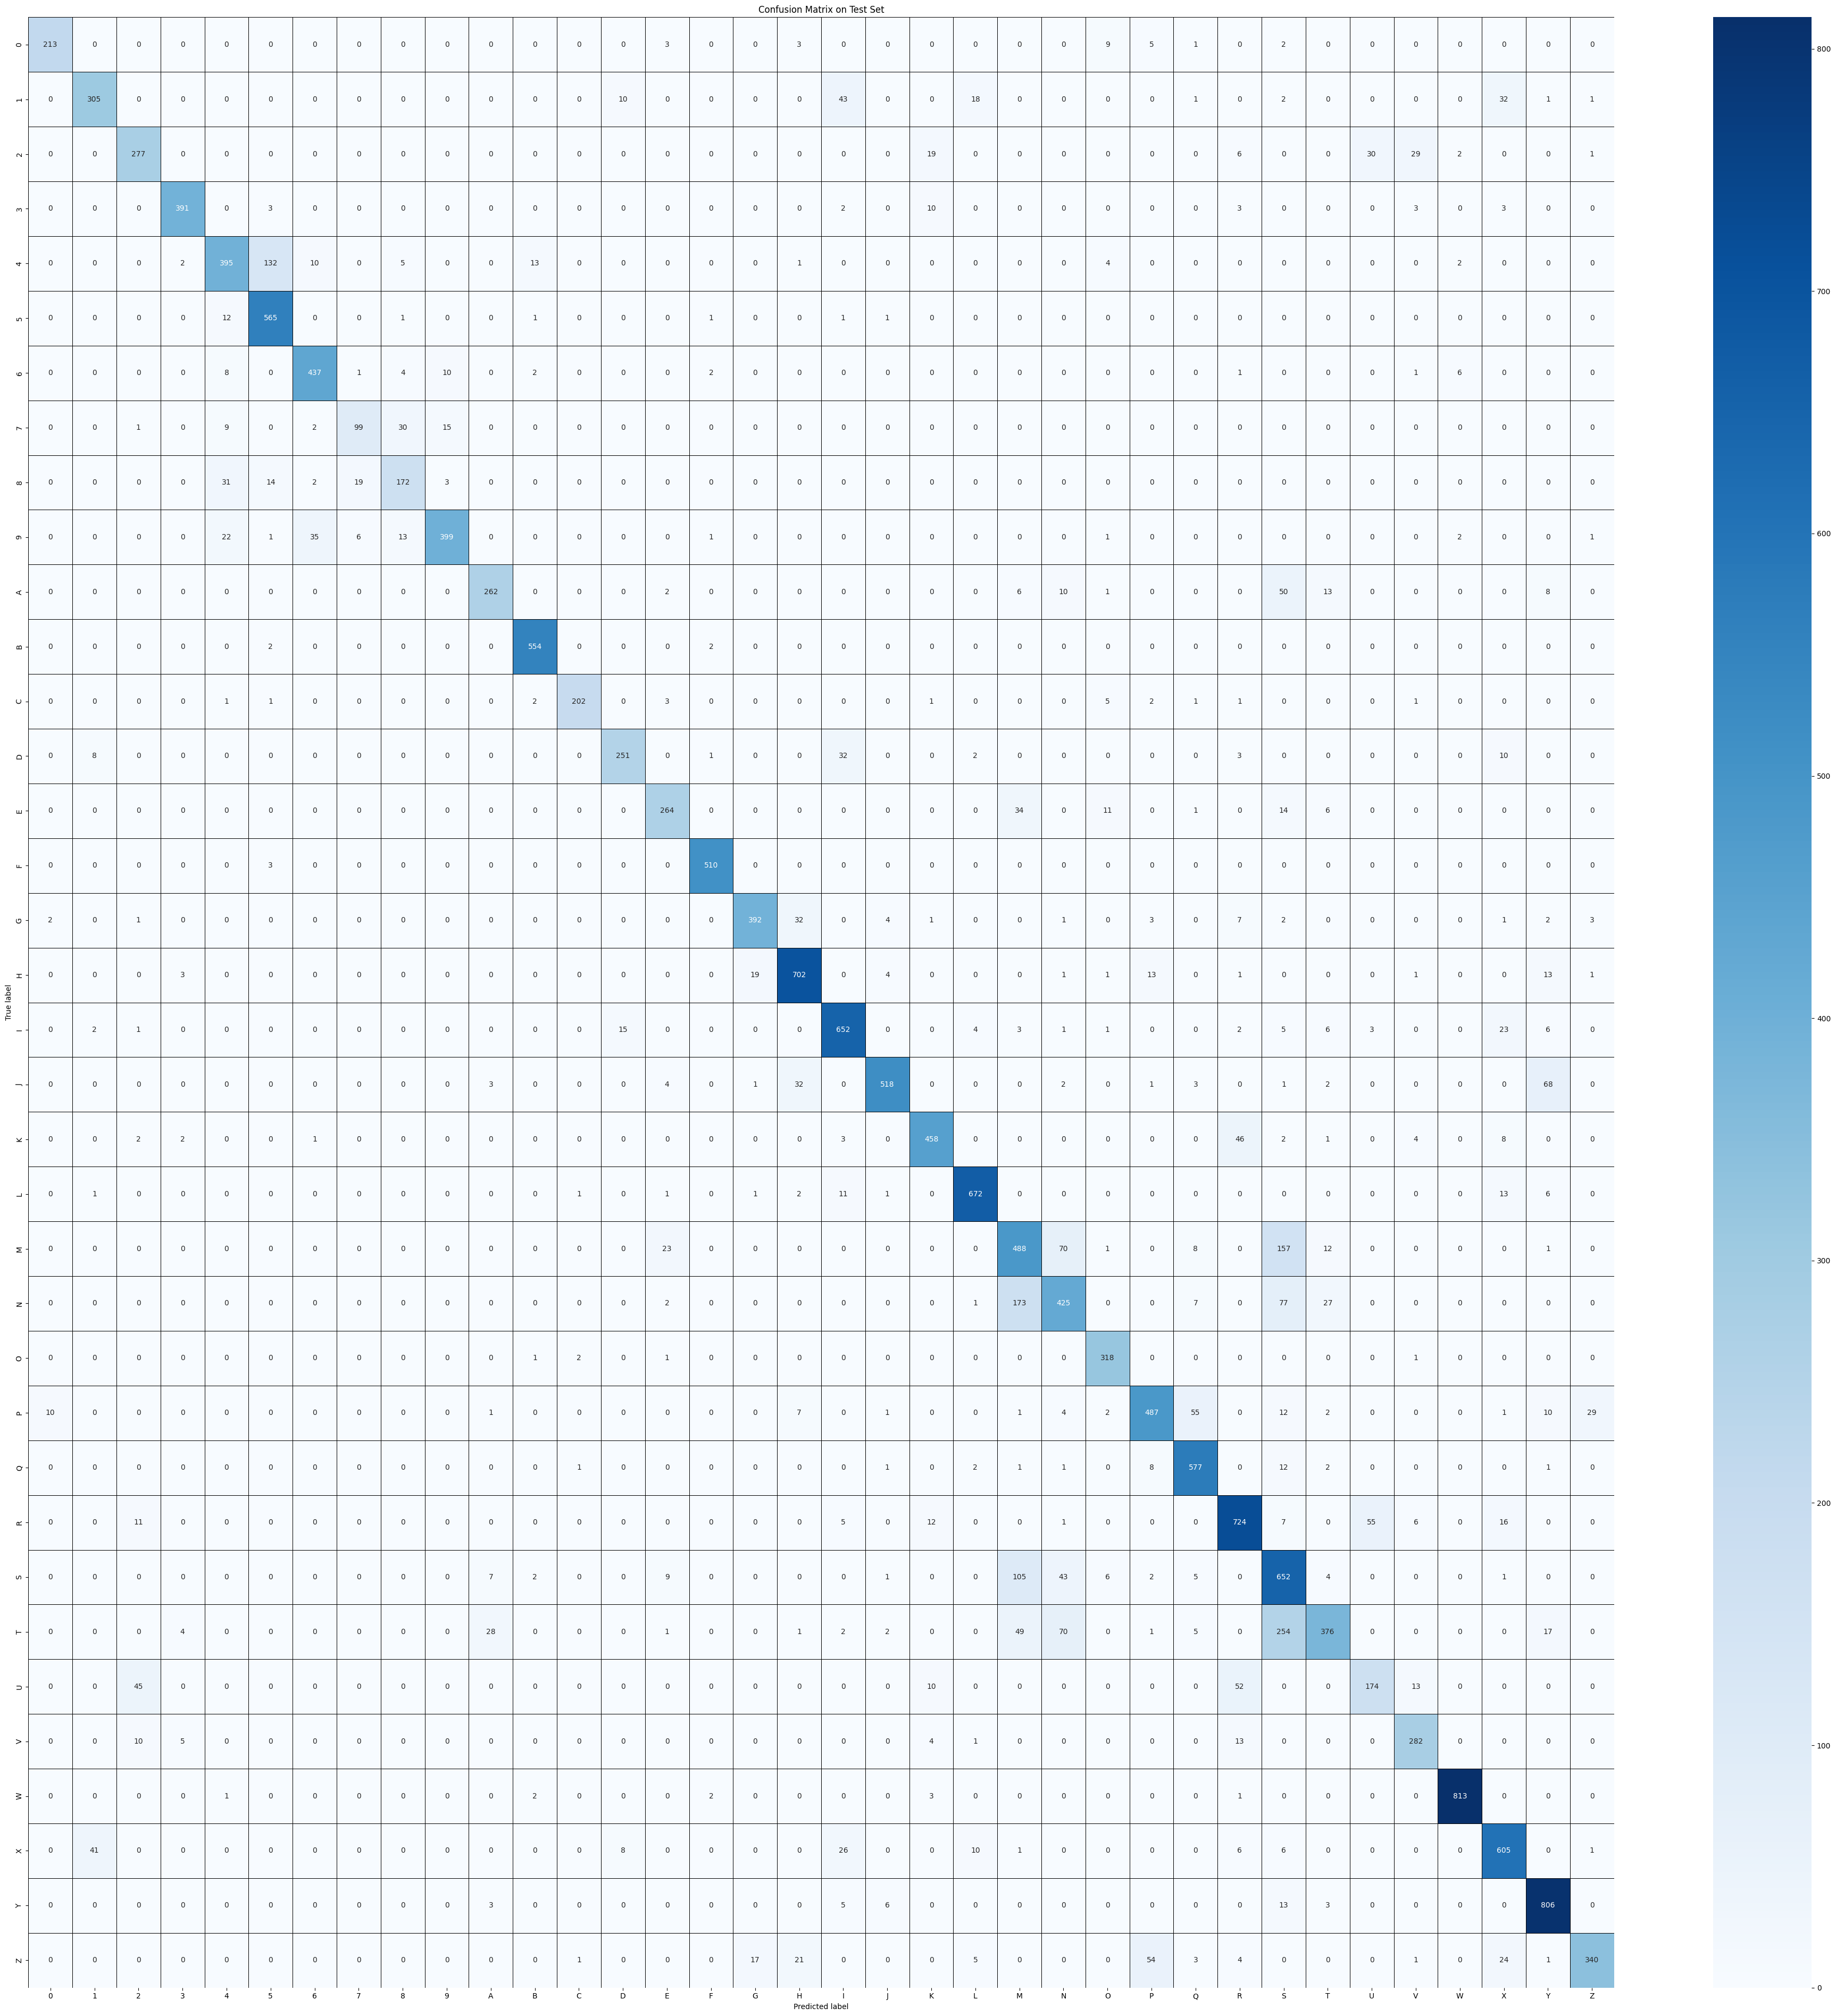


Generating Accuracy and Loss graphs...


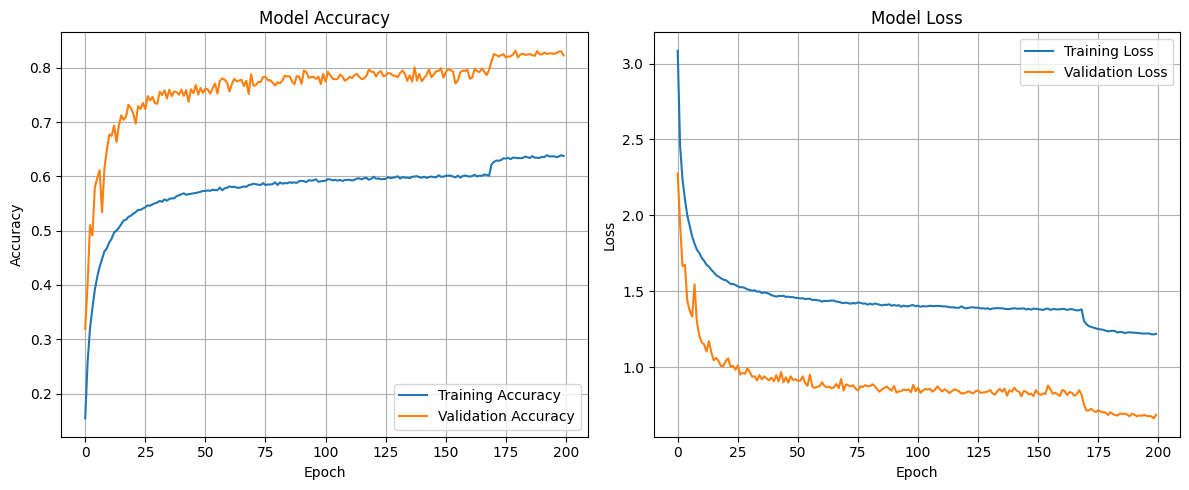


✅ Final (best) model saved to final_isl_gnn_model_full_final.h5

To analyze training, run: tensorboard --logdir logs/fit

To run real-time prediction, execute 'predict_realtime.py'.

✨ Training process successfully completed! Model and class names saved.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import datetime # For TensorBoard logs
import os



# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Custom GCN Layer (as provided previously)
class CustomGCNConv(layers.Layer):
    def __init__(self, channels, activation=None, kernel_regularizer=None, **kwargs):
        super(CustomGCNConv, self).__init__(**kwargs)
        self.channels = channels
        self.activation = keras.activations.get(activation)
        self.kernel_regularizer = keras.regularizers.get(kernel_regularizer)
        self.dense = layers.Dense(channels, kernel_regularizer=self.kernel_regularizer, use_bias=False) # Bias handled by BatchNormalization or added later

    def build(self, input_shape):
        self.bias = self.add_weight(
            name="bias",
            shape=(self.channels,),
            initializer="zeros",
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        X, A = inputs

        # Compute D_hat_inv_sqrt for symmetric normalization
        D_hat = tf.reduce_sum(A, axis=-1, keepdims=True)
        # Add a small epsilon to avoid division by zero or inf
        D_hat_inv_sqrt = tf.pow(D_hat + 1e-10, -0.5)
        D_hat_inv_sqrt = tf.where(tf.math.is_inf(D_hat_inv_sqrt), tf.zeros_like(D_hat_inv_sqrt), D_hat_inv_sqrt)

        # Symmetrically normalized adjacency matrix: D_hat_inv_sqrt @ A_hat @ D_hat_inv_sqrt
        # For batch processing, use element-wise multiplication with broadcasting
        A_norm = D_hat_inv_sqrt * A * tf.transpose(D_hat_inv_sqrt, perm=[0, 2, 1])

        # Graph convolution: A_norm @ X_transformed
        # First, apply the dense layer (W) to X
        X_transformed = self.dense(X)
        output = tf.matmul(A_norm, X_transformed)

        # Add bias
        output = output + self.bias

        # Apply activation
        if self.activation is not None:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super(CustomGCNConv, self).get_config()
        config.update({
            "channels": self.channels,
            "activation": keras.activations.serialize(self.activation),
            "kernel_regularizer": keras.regularizers.serialize(self.kernel_regularizer)
        })
        return config


# Custom Global Sum Pooling Layer
class GlobalSumPool(layers.Layer):
    def __init__(self, **kwargs):
        super(GlobalSumPool, self).__init__(**kwargs)

    def call(self, inputs):
        # Sums features of all nodes in a graph
        return tf.reduce_sum(inputs, axis=1) # Sum over the node dimension

    def get_config(self):
        return super(GlobalSumPool, self).get_config()


def build_gnn_model(input_shape_X, input_shape_A, num_classes):
    X_input = keras.Input(shape=input_shape_X, name='node_features')
    A_input = keras.Input(shape=input_shape_A, name='adjacency_matrix', dtype=tf.float32)

    # GCN Layers with Batch Normalization and Dropout
    # Increased channels and added a deeper layer for more capacity
    x = CustomGCNConv(256, activation=None, kernel_regularizer=keras.regularizers.l2(1e-4))([X_input, A_input])
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = CustomGCNConv(256, activation=None, kernel_regularizer=keras.regularizers.l2(1e-4))([x, A_input])
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = CustomGCNConv(128, activation=None, kernel_regularizer=keras.regularizers.l2(1e-4))([x, A_input])
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    # Global Pooling Layer
    x = GlobalSumPool()(x)

    # Fully Connected Layers for Classification Head
    x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    output = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=[X_input, A_input], outputs=output)
    return model

def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix on Test Set', cmap=plt.cm.Blues):
    """
    Plots the confusion matrix using actual class names.
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(len(classes) + 2, len(classes) + 2))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=classes, yticklabels=classes,
                cbar=True, linewidths=.5, linecolor='black')
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.show()

def plot_accuracy_loss(history):
    """
    Plots the training and validation accuracy and loss curves.
    """
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('accuracy_loss_curves.png')
    plt.show()

def train_model_main(dataset_path):
    print(f"\n🚀 Starting training process for ISL GNN model using data from: {dataset_path}")

    # Load and preprocess data using the ISLDataset class
    # This will also save classes.txt
    dataset = ISLDataset(dataset_path)
    (x_train, a_train, y_train_true), \
    (x_val, a_val, y_val_true), \
    (x_test, a_test, y_test_true) = dataset.load_and_preprocess_data()

    num_classes = len(dataset.classes)
    if num_classes < 2:
        raise ValueError(f"Found only {num_classes} class. At least 2 classes are required for classification.")

    # Convert integer labels to one-hot encoding for Keras
    y_train_one_hot = keras.utils.to_categorical(y_train_true, num_classes=num_classes)
    y_val_one_hot = keras.utils.to_categorical(y_val_true, num_classes=num_classes)
    y_test_one_hot = keras.utils.to_categorical(y_test_true, num_classes=num_classes)

    # Build the model
    input_shape_X = x_train.shape[1:]  # (num_landmarks, num_features_per_landmark) e.g., (21, 3)
    input_shape_A = a_train.shape[1:]  # (num_landmarks, num_landmarks) e.g., (21, 21)
    model = build_gnn_model(input_shape_X, input_shape_A, num_classes)

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005), # Slightly reduced LR
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()

    # Callbacks for better training control
    log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=70, restore_best_weights=True, verbose=1), # Increased patience
        keras.callbacks.ModelCheckpoint('best_isl_gnn_model.h5', save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=25, min_lr=1e-7, verbose=1), # Adjusted parameters
        keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
    ]

    print("\nTraining the GNN model...")
    history = model.fit(
        [x_train, a_train], y_train_one_hot,
        epochs=200, # Max epochs, EarlyStopping will stop it sooner if performance plateaus
        batch_size=32,
        validation_data=([x_val, a_val], y_val_one_hot),
        callbacks=callbacks,
        verbose=1
    )

    # Load the best model saved by ModelCheckpoint for final evaluation
    try:
        best_model = tf.keras.models.load_model('best_isl_gnn_model_final.h5',
                                                custom_objects={'CustomGCNConv': CustomGCNConv,
                                                                'GlobalSumPool': GlobalSumPool})
        print("\n✅ Loaded best model for final evaluation.")
    except Exception as e:
        print(f"\n🚫 Could not load 'best_isl_gnn_model.h5'. Using the last trained model. Error: {e}")
        best_model = model # Fallback to the last trained model if loading fails

    # Evaluate the final (best) model on the test set
    print("\n📊 Evaluating final (best) model on the test set...")
    test_loss, test_acc = best_model.evaluate([x_test, a_test], y_test_one_hot, verbose=1)
    print(f"\n🎉 Final Test Accuracy: {test_acc*100:.2f}%")
    print(f"Final Test Loss: {test_loss:.4f}")

    # Generate predictions for the confusion matrix
    y_pred_probs = best_model.predict([x_test, a_test])
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    # Plot Confusion Matrix using actual class names
    print("\nGenerating Confusion Matrix...")
    plot_confusion_matrix(y_test_true, y_pred_classes, dataset.classes, title='Confusion Matrix on Test Set')

    # Plot Accuracy and Loss graphs
    print("\nGenerating Accuracy and Loss graphs...")
    plot_accuracy_loss(history)

    # Save the final model for prediction script
    final_model_path = "final_isl_gnn_model_full_final.h5"
    best_model.save(final_model_path)
    print(f"\n✅ Final (best) model saved to {final_model_path}")

    print("\nTo analyze training, run: tensorboard --logdir logs/fit")
    print("\nTo run real-time prediction, execute 'predict_realtime.py'.")

if __name__ == '__main__':
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            tf.config.set_visible_devices(gpus[0], 'GPU')
            tf.config.experimental.set_memory_growth(gpus[0], True)
            print(f"🔥 TensorFlow is using GPU: {gpus[0].name}")
        except RuntimeError as e:
            print(e)
    else:
        print("⚠️ No GPU found, TensorFlow will use CPU. Training might be slow.")

    dataset_base_path = '/content/merged_sign/merged'

    if not os.path.exists(dataset_base_path):
        print(f"Error: Dataset path '{dataset_base_path}' not found.")
        print("Please create the 'ISL_Dataset' directory and populate it with class subfolders and images.")
        print("Example structure: ISL_Dataset/A/img_01.jpg, ISL_Dataset/B/img_01.jpg, etc.")
    else:
        try:
            train_model_main(dataset_base_path)
            print(f"\n✨ Training process successfully completed! Model and class names saved.")
        except ValueError as ve:
            print(f"\n❌ Training failed: {ve}")
        except Exception as e:
            print(f"\nAn unexpected error occurred during training: {e}")

TensorFlow version: 2.18.0
GPU device name: /device:GPU:0
